# Exploratory Data Analysis (EDA)
## Merged Industry Jobs Dataset

This notebook performs a full exploratory data analysis on `Merged_industry_jobs_-_industry_jobs.csv`, covering:

1. Dataset structure & feature types
2. Shape, missing values, duplicates
3. Target variable candidates & class distribution
4. Statistical summaries & visualizations
5. Key observations / data quality issues


## 1. Setup & Load Data

In [85]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

df = pd.read_csv("Merged_industry_jobs - industry_jobs.csv")
df.head()


,Job_ID,Link of the Job,Company,Role,Experience,PythonRequired,LinuxRequired,NetworkingRequired,AWSRequired,AzureRequired,DockerRequired,KubernetesRequired,TerraformRequired,CyberSecurityRequired,CommunicationRequired,SalaryLPA
0,1,https://cloudsoftsol.com/jobs/fresher-cloud-de...,Capgemini,Cloud Security Engineer,Fresher,5,9,8,9,6,7,9,5,8,8,9.61
1,2,https://cloudsoftsol.com/jobs/sre-devops-fresh...,HCL,Cloud Engineer,Fresher,7,10,8,7,9,9,5,7,7,8,5.42
2,3,https://cloudsoftsol.com/jobs/devops-sre-fresh...,Wipro,Cloud Engineer,Fresher,6,7,8,8,5,6,6,5,7,8,9.26
3,4,https://cloudsoftsol.com/jobs/analytical-brain...,Accenture,SOC Analyst,Fresher,9,8,9,9,5,6,7,7,6,6,9.07
4,5,https://cloudsoftsol.com/jobs/zyphra-tech-clou...,Infosys,Cloud Security Engineer,Fresher,6,6,6,8,8,8,10,9,9,6,8.58


## 2. Dataset Structure

In [86]:
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (260, 16)


In [87]:
df.dtypes


Job_ID                   int64
Link of the Job            str
Company                    str
Role                       str
Experience                 str
PythonRequired           int64
LinuxRequired            int64
NetworkingRequired       int64
AWSRequired              int64
AzureRequired            int64
DockerRequired           int64
KubernetesRequired       int64
TerraformRequired        int64
CyberSecurityRequired    int64
CommunicationRequired    int64
SalaryLPA                  str
dtype: object

In [88]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Job_ID                 260 non-null    int64
 1   Link of the Job        260 non-null    str  
 2   Company                259 non-null    str  
 3   Role                   260 non-null    str  
 4   Experience             258 non-null    str  
 5   PythonRequired         260 non-null    int64
 6   LinuxRequired          260 non-null    int64
 7   NetworkingRequired     260 non-null    int64
 8   AWSRequired            260 non-null    int64
 9   AzureRequired          260 non-null    int64
 10  DockerRequired         260 non-null    int64
 11  KubernetesRequired     260 non-null    int64
 12  TerraformRequired      260 non-null    int64
 13  CyberSecurityRequired  260 non-null    int64
 14  CommunicationRequired  260 non-null    int64
 15  SalaryLPA              173 non-null    str  
dtypes

## 3. Missing Values

In [89]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct,
    'dtype': df.dtypes
})

missing_df[missing_df['missing_count'] > 0].sort_values(
    by='missing_count',
    ascending=False
)

,missing_count,missing_pct,dtype
SalaryLPA,87,33.46,str
Experience,2,0.77,str
Company,1,0.38,str


`SalaryLPA` has the most missing data by far — 87 rows (33.5%). 
`Experience` (2 missing)
`Company` (1 missing) are negligible in comparison.

`conclusion` - We need to remove null value from SalaryLPA because it is more than 10%

## 4. Duplicate Records

In [90]:
print("duplicate", df.duplicated().sum())


duplicate 0


## 5. Feature Types & Unique Value Counts

In [91]:
skill_cols = ['PythonRequired','LinuxRequired','NetworkingRequired','AWSRequired','AzureRequired',
              'DockerRequired','KubernetesRequired','TerraformRequired','CyberSecurityRequired',
              'CommunicationRequired']

summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'n_missing': df.isnull().sum()
})
summary


,dtype,n_unique,n_missing
Job_ID,int64,260,0
Link of the Job,str,178,0
Company,str,160,1
Role,str,142,0
Experience,str,27,2
PythonRequired,int64,10,0
LinuxRequired,int64,10,0
NetworkingRequired,int64,9,0
AWSRequired,int64,10,0
AzureRequired,int64,10,0


## 6. Statistical Summary — Skill Requirement Scores

In [92]:
df[skill_cols].describe().round(2)


,PythonRequired,LinuxRequired,NetworkingRequired,AWSRequired,AzureRequired,DockerRequired,KubernetesRequired,TerraformRequired,CyberSecurityRequired,CommunicationRequired
count,260.0,260.00,260.00,260.00,260.00,260.00,260.00,260.00,260.00,260.00
mean,5.3,7.27,7.25,5.43,4.86,4.83,4.89,4.09,5.25,7.49
std,2.6,2.00,1.40,3.47,3.27,3.31,3.48,3.11,3.19,1.22
min,1.0,1.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,3.0,6.00,6.00,1.00,1.00,1.00,1.00,1.00,2.00,7.00
50%,6.0,8.00,7.00,7.00,6.00,6.00,6.00,3.00,4.00,8.00
75%,7.0,9.00,8.00,8.00,8.00,8.00,8.00,7.00,8.25,8.00
max,10.0,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00,10.00


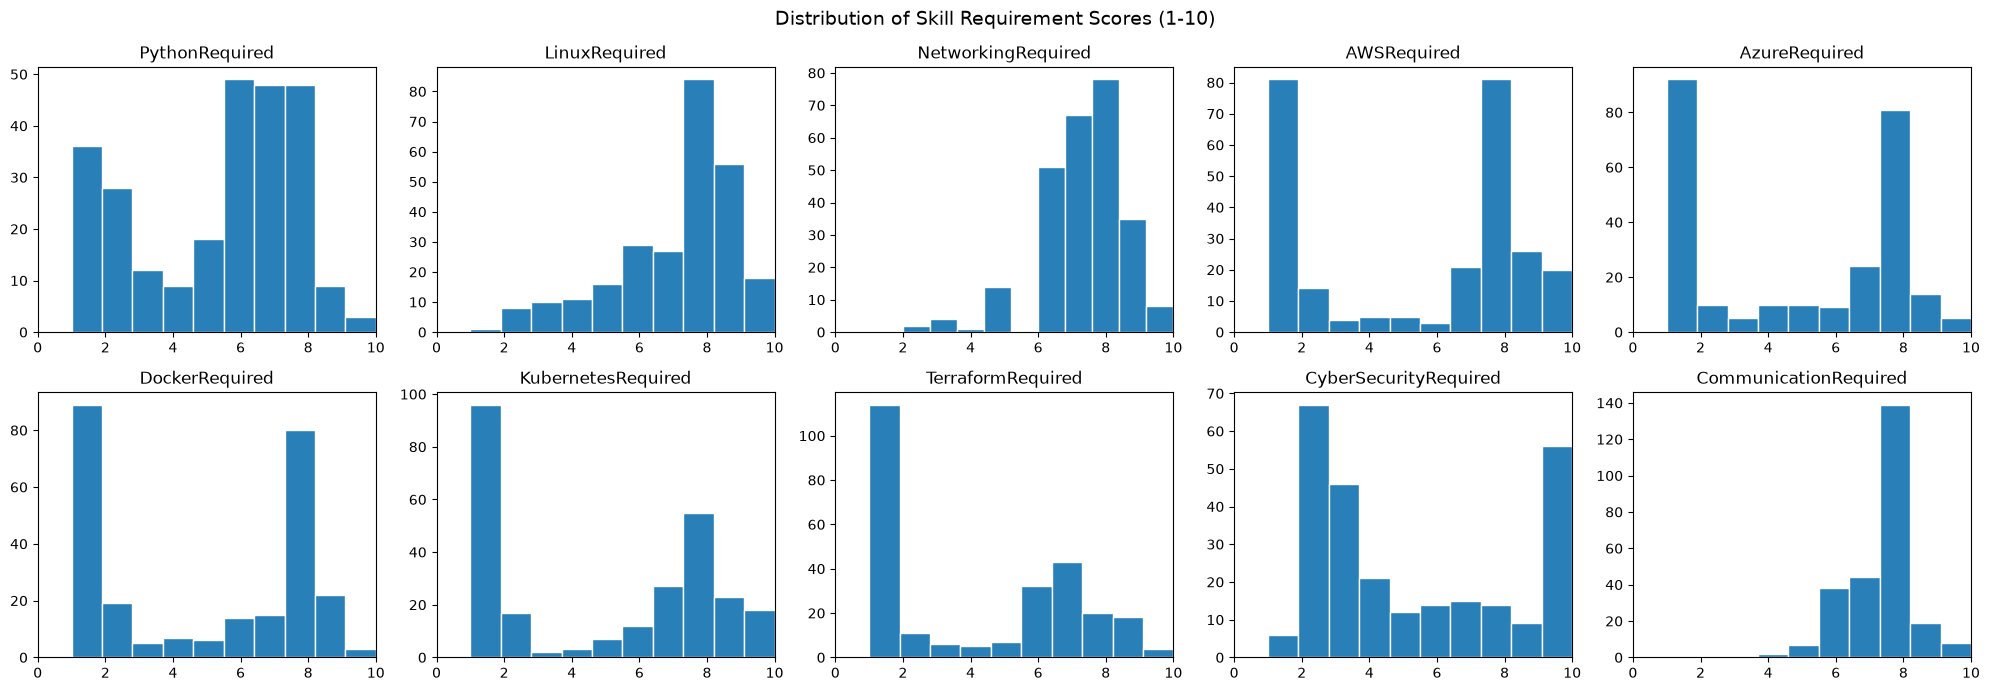

In [93]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for i, c in enumerate(skill_cols):
    axes[i].hist(df[c], bins=10, color='#2980b9', edgecolor='white')
    axes[i].set_title(c)
    axes[i].set_xlim(0, 10)
plt.suptitle('Distribution of Skill Requirement Scores (1-10)', fontsize=14)
plt.tight_layout()
plt.show()


**Observation:** Several skill columns (`AWSRequired`, `AzureRequired`, `DockerRequired`,
`KubernetesRequired`, `TerraformRequired`) are **bimodal** — one peak near 1–2 and another near 7–9 —
rather than normally distributed. This suggests postings split cleanly into "not needed" vs. "core
requirement" for these tools, consistent with two distinct job families in the data (DevOps/Cloud vs.
Security).

## 7. Correlation Between Skill Scores

In [94]:
corr = df[skill_cols].corr()
corr.round(2)


,PythonRequired,LinuxRequired,NetworkingRequired,AWSRequired,AzureRequired,DockerRequired,KubernetesRequired,TerraformRequired,CyberSecurityRequired,CommunicationRequired
PythonRequired,1.00,0.50,0.04,0.48,0.35,0.55,0.60,0.65,-0.40,0.05
LinuxRequired,0.50,1.00,0.12,0.54,0.32,0.61,0.53,0.50,-0.44,-0.18
NetworkingRequired,0.04,0.12,1.00,-0.01,-0.07,-0.06,-0.04,0.00,0.35,-0.04
AWSRequired,0.48,0.54,-0.01,1.00,0.46,0.60,0.48,0.51,-0.46,-0.16
AzureRequired,0.35,0.32,-0.07,0.46,1.00,0.52,0.51,0.45,-0.43,-0.03
DockerRequired,0.55,0.61,-0.06,0.60,0.52,1.00,0.87,0.79,-0.52,-0.13
KubernetesRequired,0.60,0.53,-0.04,0.48,0.51,0.87,1.00,0.86,-0.53,-0.05
TerraformRequired,0.65,0.50,0.00,0.51,0.45,0.79,0.86,1.00,-0.45,-0.03
CyberSecurityRequired,-0.40,-0.44,0.35,-0.46,-0.43,-0.52,-0.53,-0.45,1.00,0.02
CommunicationRequired,0.05,-0.18,-0.04,-0.16,-0.03,-0.13,-0.05,-0.03,0.02,1.00


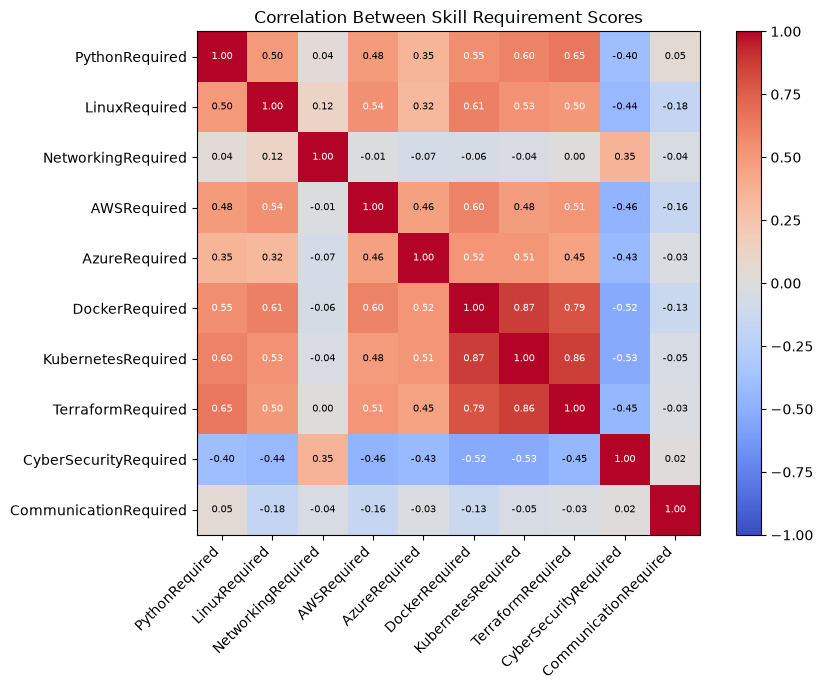

In [95]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(skill_cols))); ax.set_xticklabels(skill_cols, rotation=45, ha='right')
ax.set_yticks(range(len(skill_cols))); ax.set_yticklabels(skill_cols)
for i in range(len(skill_cols)):
    for j in range(len(skill_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=7,
                 color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
plt.colorbar(im)
ax.set_title('Correlation Between Skill Requirement Scores')
plt.tight_layout()
plt.show()


**Observation:** The DevOps/cloud toolchain skills are tightly correlated with each other
(Docker↔Kubernetes 0.87, Kubernetes↔Terraform 0.86, Docker↔Terraform 0.79). `CyberSecurityRequired` is
consistently **negatively** correlated with all DevOps skills (−0.4 to −0.53), confirming two distinct
job clusters (DevOps/Cloud vs. Security) rather than a single continuum. `CommunicationRequired` is
essentially uncorrelated with everything else — a uniformly-applied soft skill.

## 8. Target Variable Analysis

In [96]:
print("Unique raw Role values:", df['Role'].nunique())
df['Role'].value_counts().head(20)


Unique raw Role values: 142


Role
DevOps Engineer                              36
Site Reliability Engineer                    16
Site Reliability Engineer (SRE)              12
Cloud Engineer                                9
AWS DevOps Engineer                           9
Cyber Security Analyst                        8
SOC Analyst                                   7
Junior DevOps Engineer                        5
Cloud Security Engineer                       4
Cloud DevOps Engineer                         4
Cloud Operations Engineer                     3
Azure DevOps Engineer                         3
Junior Security Analyst                       2
Cyber Security Engineer                       2
Security Analyst I                            2
Security Analyst - L0                         2
Cloud Operations Engineer - Technology IT     2
Security Operations Center Associate          2
Associate Site Reliability Engineer           2
AWS Cloud Support Associate                   2
Name: count, dtype: int64

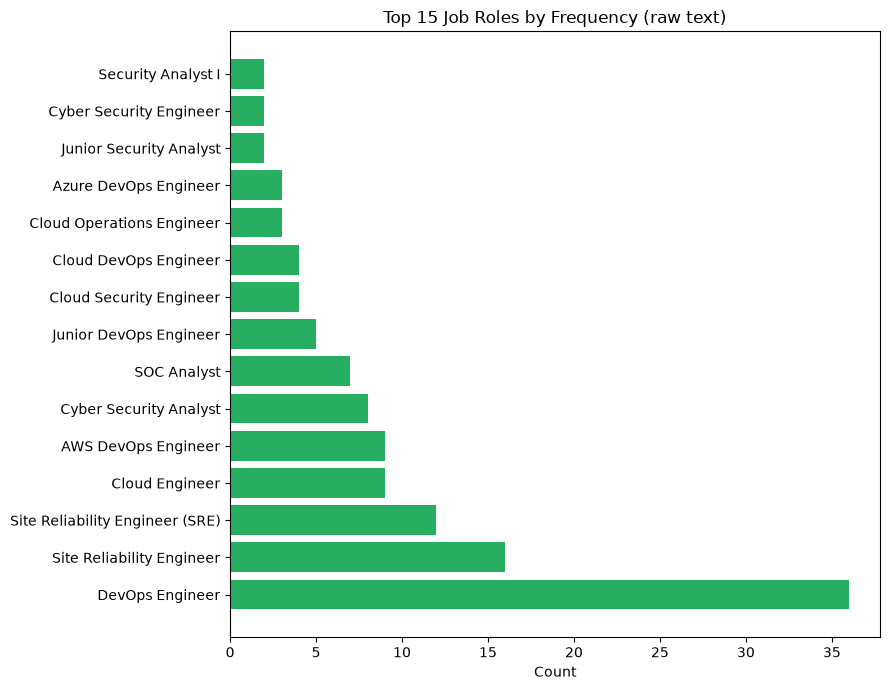

In [97]:
fig, ax = plt.subplots(figsize=(9, 7))
top_roles = df['Role'].value_counts().head(15)
ax.barh(top_roles.index, top_roles.values, color='#27ae60')
ax.set_title('Top 15 Job Roles by Frequency (raw text)')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()


## 9. Experience Column

In [98]:
df['Experience'].value_counts(dropna=False)


Experience
Fresher                                      91
0-1                                          56
Fresher – 1 Year                             20
0-2                                          11
0–3 Years                                    10
0–2 Years                                     9
Fresher–1 Year                                9
Entry Level                                   8
0–1 Years                                     7
0-1                                           6
0-1 years                                     6
0-3                                           4
Entry level                                   3
0-2 years                                     3
Fresher–2 Years                               3
NaN                                           2
0–6 months                                    1
0-4                                           1
0-2 Years                                     1
Fresher / Internship Experience Preferred     1
Entry Level                  

In [99]:
def normalize_exp(val):
    if pd.isna(val):
        return 'Unknown'
    s = str(val).lower()
    s_clean = s.replace('\u2013', '-').replace('\u2014', '-')
    if 'fresher' in s and any(ch in s for ch in ['1', '2', '3']):
        return 'Fresher-2/3 Yrs (mixed)'
    if 'fresher' in s or 'entry' in s:
        return 'Fresher/Entry Level'
    if '0-1' in s_clean:
        return '0-1 Years'
    if '0-2' in s_clean:
        return '0-2 Years'
    if '0-3' in s_clean:
        return '0-3 Years'
    return 'Other'

df['Exp_Normalized'] = df['Experience'].apply(normalize_exp)
exp_counts = df['Exp_Normalized'].value_counts()
exp_counts


Exp_Normalized
Fresher/Entry Level        105
0-1 Years                   77
Fresher-2/3 Yrs (mixed)     34
0-2 Years                   24
0-3 Years                   15
Other                        3
Unknown                      2
Name: count, dtype: int64

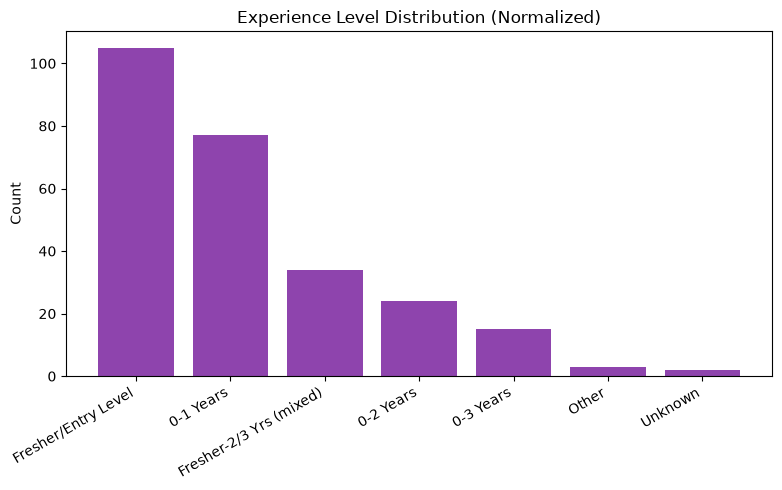

In [100]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(exp_counts.index, exp_counts.values, color='#8e44ad')
plt.xticks(rotation=30, ha='right')
ax.set_title('Experience Level Distribution (Normalized)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** 27 raw unique strings collapse into essentially the same "0–3 years / fresher" band
phrased inconsistently ("Fresher", "0-1", "Entry Level", "Fresher–1 Year", etc.). This is categorical
text that needs standardization into an ordinal scale rather than a true numeric range.

## 10. Companies

In [101]:
print("Unique companies:", df['Company'].nunique())
df['Company'].value_counts().head(15)


Unique companies: 160


Company
Cognizant                   10
Infosys                      8
Wipro                        7
TCS                          7
Capgemini                    5
UST                          5
Ally Wiredsoft Solutions     5
Searce Inc                   4
Innovature Labs              4
Robert Bosch Partners        4
Zensar                       4
Accenture                    3
Signant Health               3
ti Steps                     3
Tech Mahindra                3
Name: count, dtype: int64

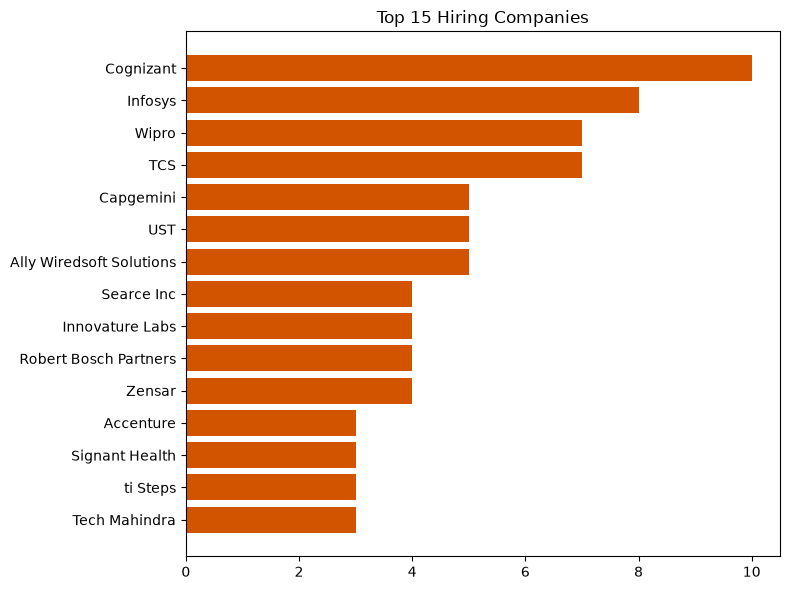

In [102]:
fig, ax = plt.subplots(figsize=(8, 6))
top_comp = df['Company'].value_counts().head(15)
ax.barh(top_comp.index[::-1], top_comp.values[::-1], color='#d35400')
ax.set_title('Top 15 Hiring Companies')
plt.tight_layout()
plt.show()


**Observation:** 160 unique companies with a long tail — no single company dominates. Cognizant (10),
Infosys (8), Wipro/TCS (7 each) are the top hirers, but most companies appear only once or twice.